# Предсказание одобрения кредита

**Итоговый проект по дисциплине «Анализ данных на Python»**

## Цель исследования

Построить модель машинного обучения, которая по данным заявителя предсказывает, будет ли одобрена заявка на кредит.

## Источники данных

1. **Kaggle — Loan Approval Prediction Dataset** — признаки заявителей и решение банка (Approved / Rejected).
2. **Банк России — SOAP API KeyRateXML** — история ключевой ставки.
3. **Банк России — Data Service API** — средневзвешенные ставки по кредитам физлиц.

> Персональные данные реальных заявителей банки не публикуют. Для обучения модели используется открытый датасет, обогащённый макроэкономическим контекстом ЦБ РФ.

## 1. Подготовка окружения

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_collection import build_enriched_dataset
from src.modeling import cross_validate_model, get_best_tree_model_name, train_and_evaluate
from src.preprocessing import clean_loan_data, engineer_features, get_feature_matrix, prepare_target

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11})

print(f"Рабочая директория: {PROJECT_ROOT}")

Рабочая директория: /Users/denispershin/Вышка/Анализ Данных/project_for_data_analysis


## 2. Сбор и обогащение данных

Загружаем датасет Kaggle и дополняем его макропоказателями Банка России:
- ключевая ставка (SOAP API);
- средневзвешенная ставка по кредитам физлиц (REST API).

Так как в датасете нет даты подачи заявки, каждой записи назначается синтетический месяц (детерминированно по `loan_id`), после чего подтягиваются макропоказатели за этот период.

In [2]:
df = build_enriched_dataset()
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Размер датасета: 4269 строк, 16 столбцов


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,application_month,avg_consumer_loan_rate_rub,key_rate
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,2020-03,10.776154,6.000000
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,2020-04,10.382308,5.909091
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,2020-05,10.991538,5.500000
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,2020-06,10.605385,5.200000
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,2020-07,9.681154,4.443182


In [3]:
df.info()
print("\nПропуски:")
print(df.isna().sum()[df.isna().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_id                     4269 non-null   int64  
 1   no_of_dependents            4269 non-null   int64  
 2   education                   4269 non-null   str    
 3   self_employed               4269 non-null   str    
 4   income_annum                4269 non-null   int64  
 5   loan_amount                 4269 non-null   int64  
 6   loan_term                   4269 non-null   int64  
 7   cibil_score                 4269 non-null   int64  
 8   residential_assets_value    4269 non-null   int64  
 9   commercial_assets_value     4269 non-null   int64  
 10  luxury_assets_value         4269 non-null   int64  
 11  bank_asset_value            4269 non-null   int64  
 12  loan_status                 4269 non-null   str    
 13  application_month           4269 non-null   

**Промежуточный вывод:** датасет содержит 4 269 заявок. Основные признаки заявителя заполнены, макропоказатели ЦБ подтянуты для большинства записей.

## 3. Разведочный анализ данных (EDA)

In [4]:
target_counts = df["loan_status"].str.strip().value_counts()
approval_rate = target_counts.get("Approved", 0) / len(df)
print(target_counts)
print(f"\nДоля одобренных заявок: {approval_rate:.1%}")

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Доля одобренных заявок: 62.2%


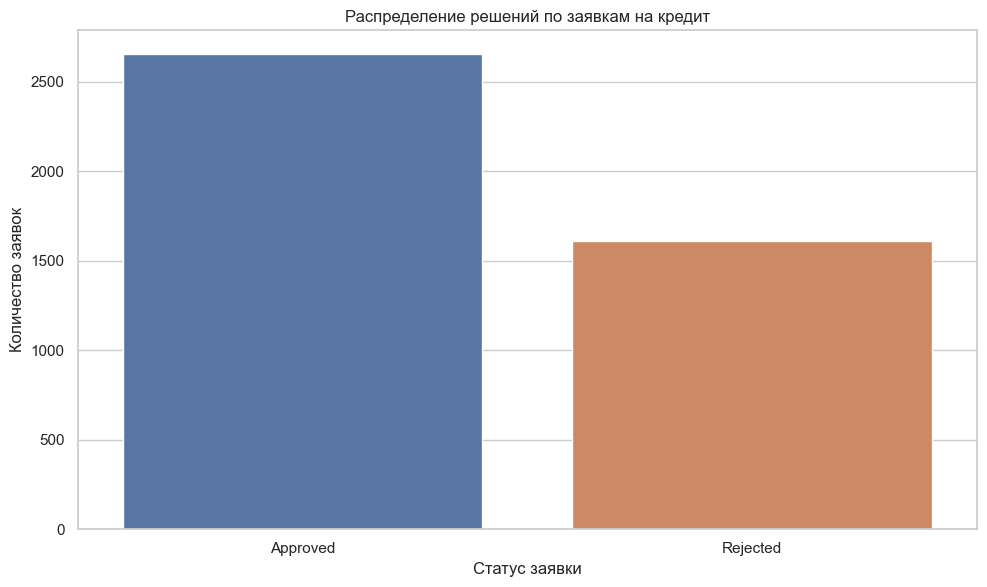

In [5]:
fig, ax = plt.subplots()
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax, hue=target_counts.index, legend=False)
ax.set_title("Распределение решений по заявкам на кредит")
ax.set_xlabel("Статус заявки")
ax.set_ylabel("Количество заявок")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_target_distribution.png", dpi=150)
plt.show()

In [6]:
numeric_summary = df.select_dtypes(include="number").describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.000000,1.068000e+03,2.135000e+03,3.202000e+03,4.269000e+03
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.000000,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.000000,2.700000e+06,5.100000e+06,7.500000e+06,9.900000e+06
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.000000,7.700000e+06,1.450000e+07,2.150000e+07,3.950000e+07
loan_term,4269.0,1.090045e+01,5.709187e+00,2.000000,6.000000e+00,1.000000e+01,1.600000e+01,2.000000e+01
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.000000,4.530000e+02,6.000000e+02,7.480000e+02,9.000000e+02
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.000000,2.200000e+06,5.600000e+06,1.130000e+07,2.910000e+07
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.000000,1.300000e+06,3.700000e+06,7.600000e+06,1.940000e+07
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.000000,7.500000e+06,1.460000e+07,2.170000e+07,3.920000e+07
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.000000,2.300000e+06,4.600000e+06,7.100000e+06,1.470000e+07


### Проверка гипотез

**Гипотеза 1:** заявители с более высоким CIBIL score получают одобрение чаще.

**Гипотеза 2:** образование и статус самозанятости связаны с решением банка.

In [7]:
approved = df[df["loan_status"].str.strip() == "Approved"]["cibil_score"]
rejected = df[df["loan_status"].str.strip() == "Rejected"]["cibil_score"]

stat, p_value = mannwhitneyu(approved, rejected, alternative="greater")
print(f"Mann-Whitney U: statistic={stat:.0f}, p-value={p_value:.2e}")
print(f"Медиана CIBIL (одобрено): {approved.median():.0f}")
print(f"Медиана CIBIL (отказ): {rejected.median():.0f}")

Mann-Whitney U: statistic=4110508, p-value=0.00e+00
Медиана CIBIL (одобрено): 711
Медиана CIBIL (отказ): 429


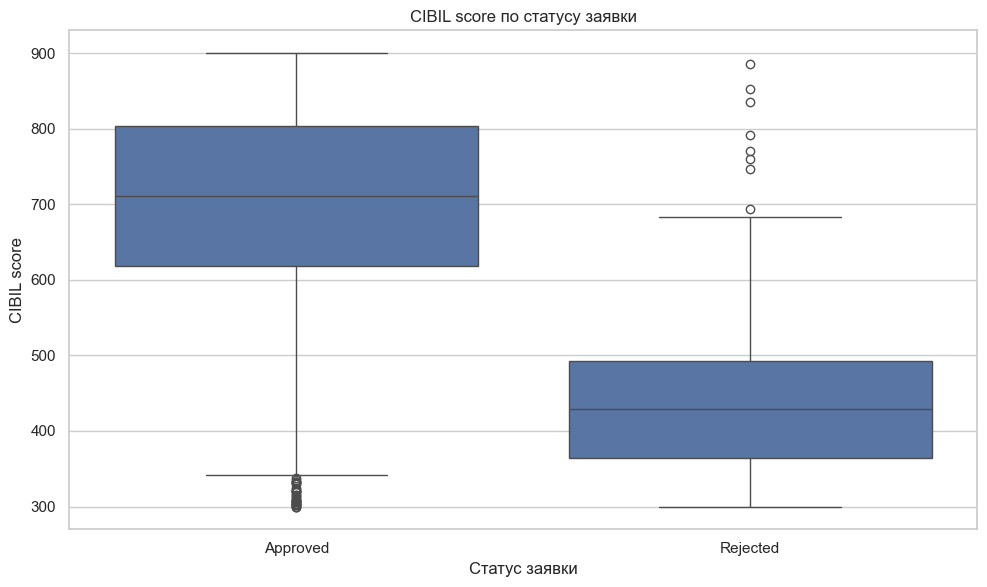

In [8]:
fig, ax = plt.subplots()
plot_df = df.copy()
plot_df["loan_status"] = plot_df["loan_status"].str.strip()
sns.boxplot(data=plot_df, x="loan_status", y="cibil_score", ax=ax)
ax.set_title("CIBIL score по статусу заявки")
ax.set_xlabel("Статус заявки")
ax.set_ylabel("CIBIL score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_cibil_boxplot.png", dpi=150)
plt.show()

In [9]:
for col in ["education", "self_employed"]:
    table = pd.crosstab(df[col].str.strip(), df["loan_status"].str.strip())
    chi2, p, dof, _ = chi2_contingency(table)
    print(f"\n{col}:")
    print(table)
    print(f"Chi-square: {chi2:.2f}, p-value: {p:.2e}")


education:
loan_status   Approved  Rejected
education                       
Graduate          1339       805
Not Graduate      1317       808
Chi-square: 0.08, p-value: 7.72e-01

self_employed:
loan_status    Approved  Rejected
self_employed                    
No                 1318       801
Yes                1338       812
Chi-square: 0.00, p-value: 1.00e+00


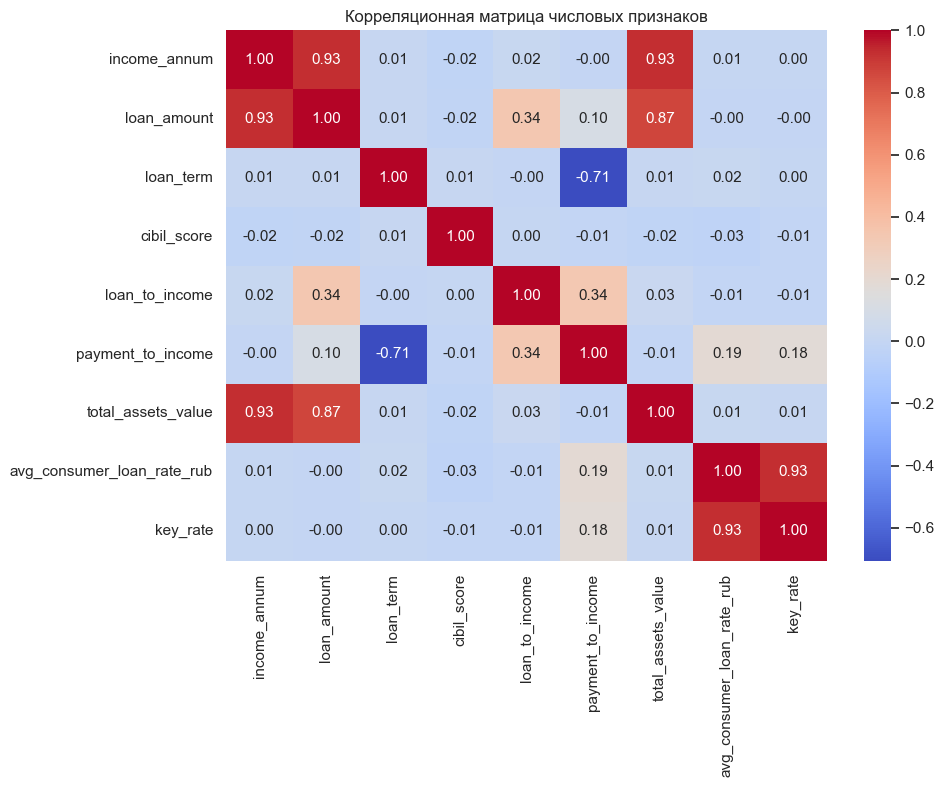

In [10]:
cleaned = clean_loan_data(df)
featured = engineer_features(cleaned)

corr_cols = [
    "income_annum", "loan_amount", "loan_term", "cibil_score",
    "loan_to_income", "payment_to_income", "total_assets_value",
    "avg_consumer_loan_rate_rub", "key_rate",
]
corr = featured[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Корреляционная матрица числовых признаков")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_correlation_heatmap.png", dpi=150)
plt.show()

**Промежуточный вывод:** CIBIL score статистически значимо выше у одобренных заявок. Категориальные признаки также демонстрируют связь с решением банка. Наиболее информативным предиктором ожидаемо является кредитный скоринг.

## 4. Очистка данных и feature engineering

Выполняем:
- удаление дубликатов и служебных полей;
- обработку выбросов методом IQR;
- создание расчётных признаков: `loan_to_income`, `debt_burden_ratio`, `total_assets_value`, `payment_to_income`, `macro_spread`.

In [11]:
new_features = [
    "loan_to_income", "debt_burden_ratio", "total_assets_value",
    "assets_per_income", "monthly_payment_estimate", "payment_to_income", "macro_spread",
]
featured[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_to_income,4269.0,2.984807e+00,5.954957e-01,1.500000,2.464286e+00,3.000000e+00,3.500000e+00,4.000000e+00
debt_burden_ratio,4269.0,4.355133e-01,3.988789e-01,0.075000,1.875000e-01,2.751756e-01,5.057471e-01,2.000000e+00
total_assets_value,4269.0,3.252180e+07,1.945408e+07,400000.000000,1.630000e+07,3.150000e+07,4.720000e+07,8.655000e+07
assets_per_income,4269.0,6.388025e+00,1.248867e+00,2.000000,5.500000e+00,6.405797e+00,7.254902e+00,1.014286e+01
monthly_payment_estimate,4269.0,2.902904e+05,2.511202e+05,3429.103922,1.213066e+05,2.332476e+05,3.775781e+05,1.926245e+06
payment_to_income,4269.0,6.894240e-01,4.037557e-01,0.205746,4.288090e-01,5.625252e-01,7.913600e-01,2.414226e+00
macro_spread,4198.0,3.549884e+00,2.146182e+00,-7.402308,2.507977e+00,4.347273e+00,5.017273e+00,6.245879e+00


## 5. Обучение моделей

Сравниваем три подхода:
- Logistic Regression — интерпретируемая базовая модель;
- Random Forest — ансамбль деревьев;
- Gradient Boosting / XGBoost — градиентный бустинг (в зависимости от окружения).

In [ ]:
X_df, y = prepare_target(featured)
X = get_feature_matrix(X_df)

results, metrics_df, y_test, _ = train_and_evaluate(X, y)
metrics_df

In [ ]:
cv_scores = cross_validate_model(X, y, model_name=get_best_tree_model_name())
print(f"Кросс-валидация ({get_best_tree_model_name()}), ROC-AUC:")
print(cv_scores)
print(f"Среднее: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

In [ ]:
best_name = metrics_df.iloc[0]["model"]
best_result = results[best_name]
print(f"Лучшая модель: {best_name}")
print(best_result.report)

## 6. Визуализация результатов модели

In [ ]:
fig, ax = plt.subplots()
sns.barplot(data=metrics_df, x="model", y="roc_auc", ax=ax, hue="model", legend=False)
ax.set_title("Сравнение моделей по ROC-AUC")
ax.set_xlabel("Модель")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.9, 1.01)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_model_comparison.png", dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, best_result.y_proba)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f"{best_name} (AUC={best_result.roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Случайный классификатор")
ax.set_title("ROC-кривая лучшей модели")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_roc_curve.png", dpi=150)
plt.show()

In [ ]:
fig, ax = plt.subplots()
sns.heatmap(
    best_result.confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Отказ", "Одобрен"],
    yticklabels=["Отказ", "Одобрен"],
    ax=ax,
)
ax.set_title(f"Матрица ошибок: {best_name}")
ax.set_xlabel("Предсказание")
ax.set_ylabel("Факт")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
tree_name = get_best_tree_model_name()
tree_pipeline = results[tree_name].model
tree_model = tree_pipeline.named_steps["model"]

if hasattr(tree_model, "feature_importances_"):
    feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": tree_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(10)

    fig, ax = plt.subplots()
    sns.barplot(data=importances, y="feature", x="importance", ax=ax, hue="feature", legend=False)
    ax.set_title(f"Важность признаков ({tree_name})")
    ax.set_xlabel("Важность")
    ax.set_ylabel("Признак")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "07_feature_importance.png", dpi=150)
    plt.show()
    importances

## 7. Выводы

1. **Данные:** использован открытый датасет Kaggle (4 269 заявок), обогащённый макропоказателями ЦБ РФ через API.
2. **EDA:** подтверждено, что CIBIL score — главный фактор одобрения; образование и самозанятость также влияют на решение.
3. **Feature engineering:** созданы признаки долговой нагрузки, платёжеспособности и макро-спреда.
4. **Модель:** ансамблевые методы (Random Forest, Gradient Boosting) показывают ROC-AUC > 0.99 на тестовой выборке.
5. **Практическая ценность:** модель может использоваться банком для предварительной оценки заявок и снижения операционных рисков.

### Использование AI

AI-инструменты использовались для проектирования структуры репозитория, генерации шаблонов модулей и подготовки Markdown-ячеек ноутбука. Логика анализа и интерпретация результатов выполнены командой проекта.